In [1]:
from mslandcover.inference import histogram_match_image
from mslandcover.data.utils import load_histogram_data
import rioxarray as rxr
import matplotlib.pyplot as plt

In [2]:
source_histograms = load_histogram_data(state='MS', year=2016)
target_histograms = load_histogram_data(state='MS', year=2023)

test_image = rxr.open_rasterio('/scratch/dhester/ms_naip/2016/1453.tif')
new_image = rxr.open_rasterio('/scratch/dhester/ms_naip/2023/1453.tif')

In [18]:
matched_image = histogram_match_image(
    test_image,
    source_histograms,
    target_histograms,
)

In [11]:
matched_image = histogram_match_image(
    matched_image,
    source_histograms,
    target_histograms,
)

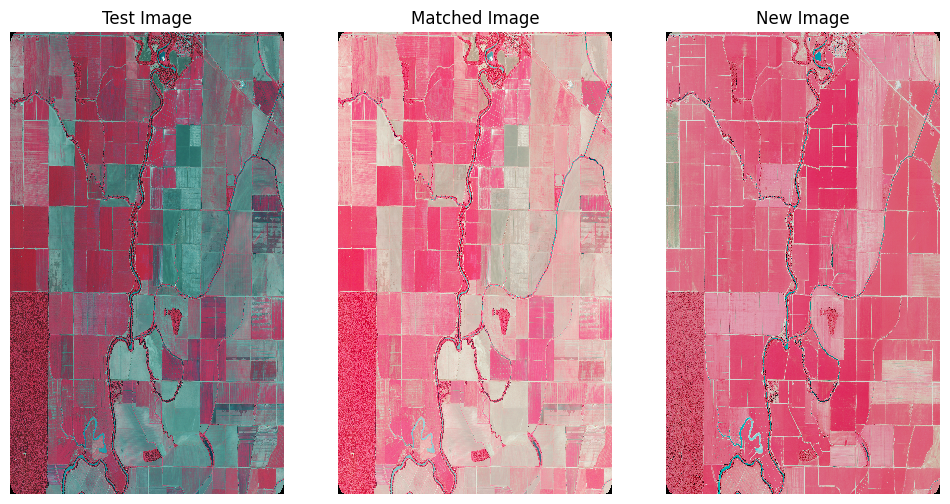

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(12, 6))
test_image.sel(band=[4, 1, 2]).plot.imshow(ax=ax[0], cmap='gray')
matched_image.sel(band=[4, 1, 2]).plot.imshow(ax=ax[1], cmap='gray')
new_image.sel(band=[4, 1, 2]).plot.imshow(ax=ax[2], cmap='gray')
ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')
ax[0].set_title('Test Image')
ax[1].set_title('Matched Image')
ax[2].set_title('New Image')
plt.show()

(0.0, 255.0)

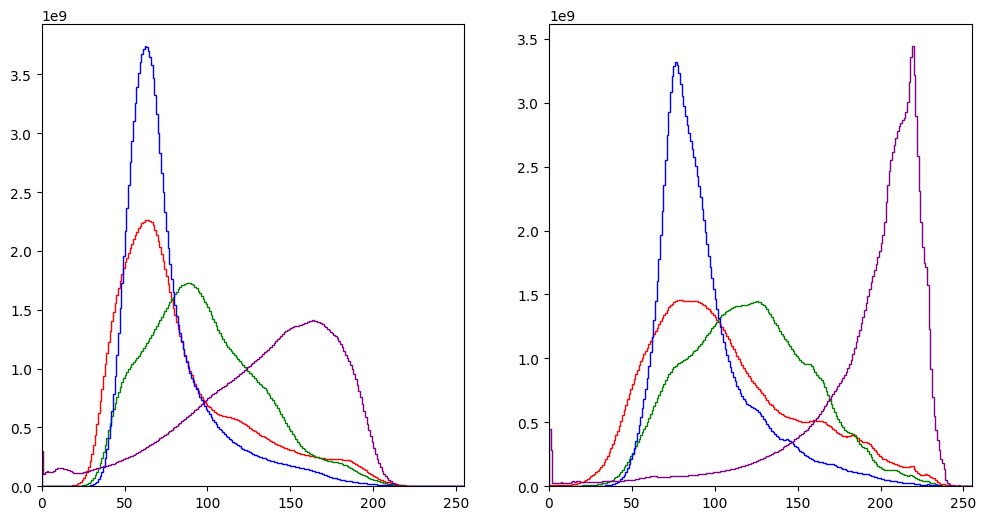

In [ ]:
colors = ['red', 'green', 'blue', 'purple']
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
for i, band in enumerate(colors):
    ax[0].stairs(source_histograms[i], color=band, label=f'Source {band}')
    ax[1].stairs(target_histograms[i], color=band, label=f'Target {band}')

ax[0].set_xlim(0, 255)
ax[1].set_xlim(0, 255)

In [14]:
import torch
from mslandcover.models import UNet, ResNetBackboneUNet
from mslandcover.inference import RasterProcessor

model = UNet(
    ResNetBackboneUNet(in_channels=3, pretrained=False),
)
model.load_state_dict(torch.load('./weights/finetune_20250612/unet/byol/3_bands/presize_256/prebatch_128/randinit_false/frozenencoder_false/750/fold_3/best_model.pth'))

mean = torch.load('./weights/pretrain_mean.pth')
std = torch.load('./weights/pretrain_std.pth')
model.eval()

/tmp/ipykernel_244656/1489856687.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('./weights/finetune_20250612/unet/byol/3_bands/presize_

UNet(
  (backbone): ResNetBackboneUNet(
    (initial): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
       

In [ ]:
processor = RasterProcessor(
    model,
    stride=128,
    mean=mean,
    std=std,
)

In [ ]:
test_preds = processor.process_raster(test_image.sel(band=[1, 2, 4]) / 255.0)

In [ ]:
matched_preds = processor.process_raster(matched_image.sel(band=[1, 2, 4]) / 255.0)
new_preds = processor.process_raster(new_image.sel(band=[1, 2, 4]) / 255.0)

In [30]:
from mslandcover.config import LEGEND_COLORS_RGB

def colorize_predictions(predictions, legend_colors):
    colorized = torch.zeros((predictions.shape[0], predictions.shape[1], 3), dtype=torch.uint8)
    for i in range(len(legend_colors)):
        mask = predictions == i
        colorized[mask] = torch.tensor(legend_colors[i], dtype=torch.uint8)
    return colorized.numpy()

test_colorized = colorize_predictions(test_preds.argmax(axis=0) + 1, LEGEND_COLORS_RGB)
matched_colorized = colorize_predictions(matched_preds.argmax(axis=0) + 1, LEGEND_COLORS_RGB)
new_colorized = colorize_predictions(new_preds.argmax(axis=0) + 1, LEGEND_COLORS_RGB)

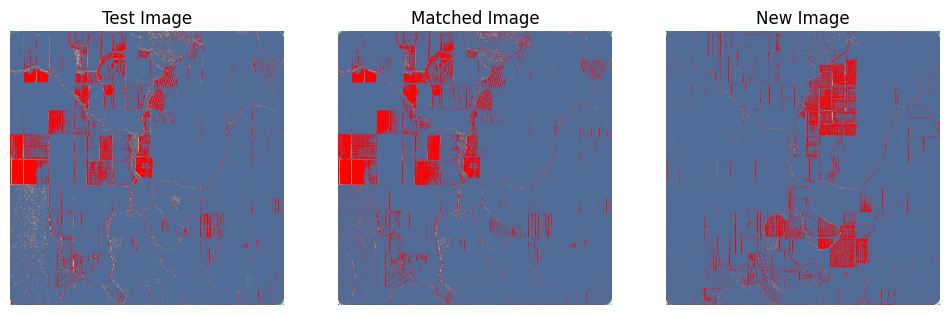

In [33]:
fig, ax = plt.subplots(1, 3, figsize=(12, 6))

ax[0].imshow(test_colorized)
ax[1].imshow(matched_colorized)
ax[2].imshow(new_colorized)

ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')
ax[0].set_title('Test Image')
ax[1].set_title('Matched Image')
ax[2].set_title('New Image')
plt.show()


In [34]:
test_preds.argmax(axis=0) + 1

array([[5, 1, 1, ..., 1, 5, 1],
       [1, 1, 1, ..., 1, 5, 1],
       [1, 1, 1, ..., 1, 5, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 3, 3, 1],
       [1, 1, 1, ..., 1, 1, 1]])